<a href="https://colab.research.google.com/github/blaisehuber/TP-Acces-et-ordonnancement/blob/main/irsa-student-version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### NAME, first name: Huber, Blaise

## TP TELECOM204 – Coded Slotted Aloha (M. Coupechoux)

### Subject

In this TP, we compute the asymptotic performance of coded slotted Aloha MAC protocols and we simulate one of its variants. For every question, there is a Python program to complete. You may add some text/code to explain your approach, comment the results or showing intermediate results. Please send me your code and responses in Jupyter-notebook format (yourname.ipynb) at marceau.coupechoux@telecom-paris.fr.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/coupecho/coded-slotted-aloha/blob/main/irsa-student-version.ipynb)

### Exercise 1 : Contention Resolution Diversity Slotted Aloha (CRDSA)

In this first part of the TP, we simulate a network adopting CRDSA and implement the decoding algorithm.

We consider the following variables:
* `Gp` the average number of transmitted packets per slot (the load)
* `M` the number of slots per frame
* `Tcrdsa` the throughput in number of successfully transmitted packet per slot
* `PLcrdsa` the packet loss rate
* `Nitsim` the number of iterations (frame) for the simulations
* `nbsuc` the number of decoded packets
* `nbpackets` the total number of packets
* `nbpacketsperframe` the number of packets per frame

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import random

G = np.arange(0.05,2,0.05,dtype=float)
M = 100
Nit = 20
Nitsim = 500
PLcrdsa = np.ndarray(len(G))
Tcrdsa = np.ndarray(len(G))
nbsuc = np.ndarray(len(G))
nbpackets = np.ndarray(len(G))
nbpacketsperframe = np.ndarray(len(G),dtype=np.int16)

1. **Implement the transmission and the decoding algorithm of CRDSA in the following loop**

Text(0.5, 1.0, 'PLcrdsa')

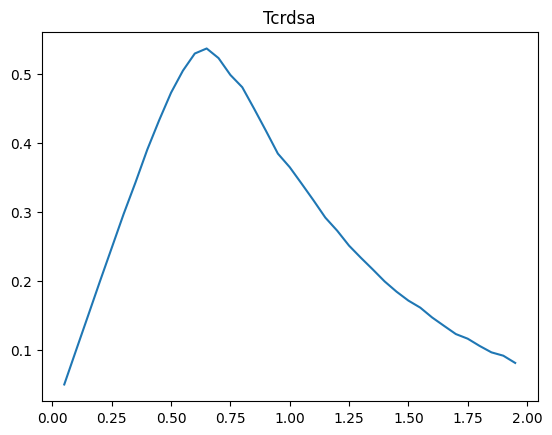

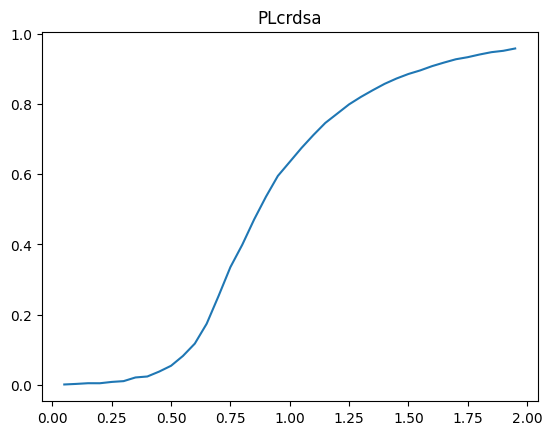

In [43]:
for g in range(len(G)): # loop on the different loads

    nbpackets[g] = 0    #nombre de paquets total
    nbsuc[g] = 0    #nombre de paquets décodés
    nbpacketsperframe[g] = np.floor(G[g]*M)     #nombre de paquets par frame (nombre de paquets moyen par slot fois le nombre de slots)

    for i in range(Nitsim):     # loop on the number of frames
        nbpackets[g] = nbpackets[g] + nbpacketsperframe[g] #on ajoute les paquets de la frame actuelle au nombre total

        # transmit duplicates here
        frame = [[] for k in range(M)]    #frame avec N slots
        for packet in range(nbpacketsperframe[g]):
            slots = random.sample(range(M), 2)      #position des deux slots avec les deux copies
            frame[slots[0]].append((packet, slots[1]))  #on stocke l'identifiant (numéro du packet) et l'emplacement de l'autres copie
            frame[slots[1]].append((packet, slots[0]))

        # decoding algorithm here
        for iteration in range(Nit):
            bloqué = True
            for slot in range(M):
                if len(frame[slot]) ==  1:
                    (packet, emplacement_copie) = frame[slot][0]
                    frame[emplacement_copie] = [(p, e) for (p, e) in frame[emplacement_copie] if p != packet]
                    nbsuc[g] += 1
                    frame[slot]=[]
                    bloqué = False

            if bloqué:
                break # bloqué ou terminé




Tcrdsa = nbsuc/(Nitsim*M)    # throughput of CRDSA
PLcrdsa = 1 - Tcrdsa/G   # packet loss rate od CRDSA

# Pour voir à quoi ça ressemble
plt.figure(1)
plt.plot(G, Tcrdsa)
plt.title("Tcrdsa")
plt.figure(2)
plt.plot(G, PLcrdsa)
plt.title("PLcrdsa")

2. **Plot the throughput of CRDSA as a function of the load and compare to the throughput of slotted Aloha**

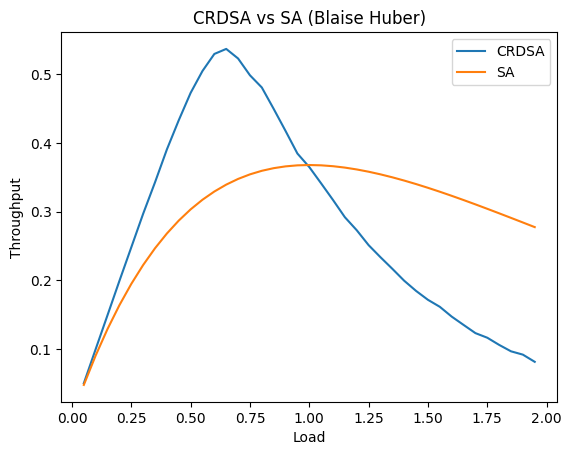

In [44]:
TSA = G * np.exp(-G) # throughput of slotted ALOHA
fig, ax = plt.subplots()
ax.plot(G, Tcrdsa, label='CRDSA')
ax.plot(G, TSA, label='SA')
ax.set_xlabel('Load')  # Add an x-label to the axes.
ax.set_ylabel('Throughput')  # Add a y-label to the axes.
ax.set_title("CRDSA vs SA (Blaise Huber)")  # Add a title to the axes.
ax.legend();  # Add a legend.

3. **Plot the packet loss rate of CRDSA**

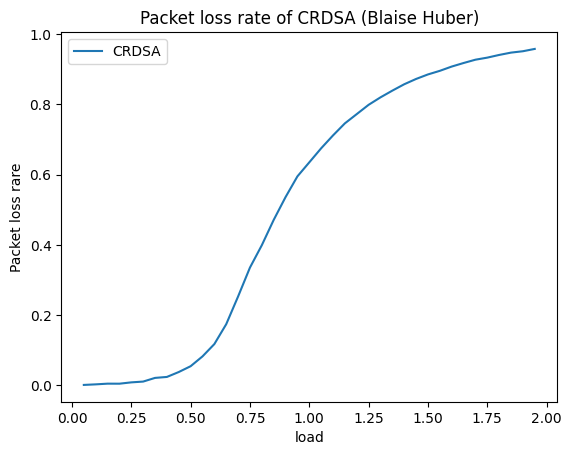

In [45]:
fig, ax = plt.subplots()
ax.plot(G, PLcrdsa, label='CRDSA')
ax.set_xlabel('load')  # Add an x-label to the axes.
ax.set_ylabel('Packet loss rare')  # Add a y-label to the axes.
ax.set_title("Packet loss rate of CRDSA (Blaise Huber)")  # Add a title to the axes.
ax.legend();  # Add a legend.

### Exercise 2 : Irregular Repetition Slotted Aloha (IRSA)

In this second part of the TP, we want to compute the packet loss rate and the throughput of IRSA for a given burst degree distribution.

We consider the following variables:
* `Lambda` is the burst node degree distribution
* `lambdal` is the egde-perspective burst node degree distribution
* `rhol` is the edge-perspective slot node degree distribution
* `p` is the probability that an edge at a burst node is unknown
* `q` is the probability that an edge at a slot node is unknown
* `Nbiter` is the number of iterations for the fixed point equation
* `G` is the load
* `PL` is the packet loss rate
* `T` is the throughput

In [46]:
import numpy as np
import matplotlib.pyplot as plt
Lambda = np.array([0,0,0.5,0.28,0,0,0,0,0.22])
Lambda = np.array([0,0,0,1])
Nbiter = 100
p0 = 1
q0 = 1
G = np.arange(0,2,0.01,dtype=float)
PL = np.ndarray(len(G))
T = np.ndarray(len(G))

1. **Compute the average repetition rate.**

In [47]:
def computeLambdaprime1(Lambda):
    # compute Lambda'(1) here
    l = np.arange(len(Lambda))
    return np.sum(l * Lambda)

2. **Derive `lambdal` from `Lambda`.**

In [48]:
def computelambdal(Lambda):
    # compute lambda_l here
    l = np.arange(len(Lambda))
    return l * Lambda / computeLambdaprime1(Lambda)


3. **Define the fixed point function that will be used to compute iteratively `p`and `q`.**

In [49]:
def fixedpointfunction(p,q,G,Lambdaprime1,lambdal):
    # implement the fixed point function and return p and q
    l = np.arange(len(lambdal))
    q = np.sum(lambdal * p ** np.maximum(l - 1, 0))
    p = 1 - np.exp(-q * G * Lambdaprime1)
    return p, q

4. **Compute the packet loss rate.**

In [50]:
def packetloss(p,G,Lambdaprime1,Lambda):
    # compute the packet loss rate here
    l = np.arange(len(Lambda))
    return np.sum(Lambda * p ** l)

5. **This is the main program. Compute iteratively `p`and `q`using the fixed point equation.**

In [51]:
# initialize lambda_l and Lambda'(1) here
Lambdaprime1 = computeLambdaprime1(Lambda)
lambdal = computelambdal(Lambda)

for i in range(len(G)):
    # loop on load
    p = p0
    q = q0
    for j in range(Nbiter):
        # iterate the fixed point here
        p, q = fixedpointfunction(p, q, G[i], Lambdaprime1, lambdal)
    PL[i] = packetloss(p, G[i], Lambdaprime1, Lambda)
    T[i] = G[i] * (1 - PL[i])

6. **Show the packet loss rate as a function of the load.**

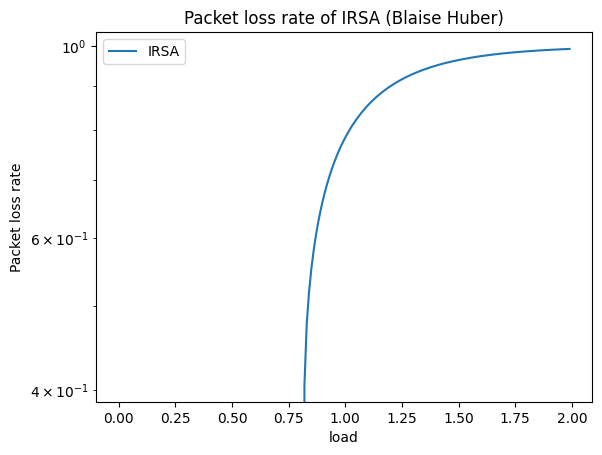

In [52]:
fig, ax = plt.subplots()
ax.semilogy(G, PL, label='IRSA')
ax.set_xlabel('load')  # Add an x-label to the axes.
ax.set_ylabel('Packet loss rate')  # Add a y-label to the axes.
ax.set_title("Packet loss rate of IRSA (Blaise Huber)")  # Add a title to the axes.
ax.legend();  # Add a legend.

7. **Show the throughput as a function of the load.**

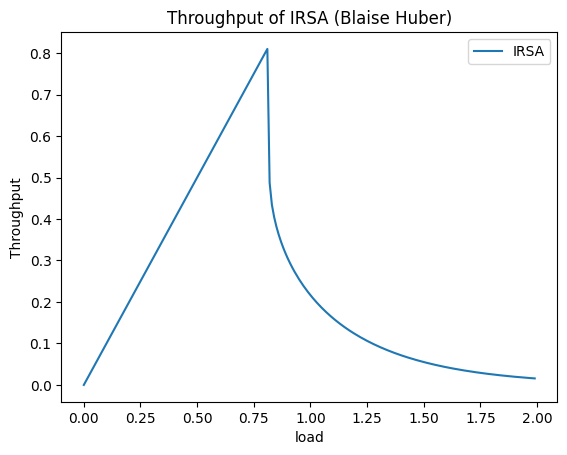

In [53]:
fig, ax = plt.subplots()
ax.plot(G, T, label='IRSA')
ax.set_xlabel('load')  # Add an x-label to the axes.
ax.set_ylabel('Throughput')  # Add a y-label to the axes.
ax.set_title("Throughput of IRSA (Blaise Huber)")  # Add a title to the axes.
ax.legend();  # Add a legend.

8. **Compare in a figure the performance of IRSA and traditional slotted Aloha in terms of throughput.**

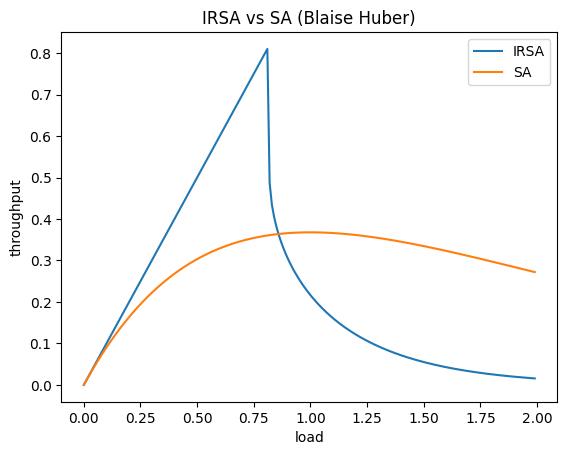

In [54]:
TSA = G * np.exp(-G) # compute here the throughput of slotted Aloha
fig, ax = plt.subplots()
ax.plot(G, T, label='IRSA')
ax.plot(G, TSA, label='SA')
ax.set_xlabel('load')  # Add an x-label to the axes.
ax.set_ylabel('throughput')  # Add a y-label to the axes.
ax.set_title("IRSA vs SA (Blaise Huber)")  # Add a title to the axes.
ax.legend();  # Add a legend.

9. **Comment the results**

Le graphe montre qu'IRSA avec la distribution Λ(x) = 0.5x² + 0.28x³ + 0.22x⁸
surpasse largement le Slotted Aloha pour des valeurs de charge plus petites que 1 environ.

Le SA atteint un débit maximum de 1/e ≈ 0.37 pour une charge de G = 1, puis décroît selon une pente quasi constante.

IRSA présente un comportement avec un seuil : en dessous de G ≈ 0.9, le décodeur SIC itératif résout presque toutes les collisions et le débit croît quasi linéairement avec la charge (T ≈ G). Au-dessus de 0.9, le décodeur ne converge plus et le débit s'effondre brutalement.

Le débit maximum d'IRSA (≈0.8) est plus du double de celui du SA (≈0.37), au prix d'un nombre moyen de transmissions par utilisateur plus élevé (E[d] = 3.6 d'après les slides de cours, contre 1 pour le SA), ce qui réduit l'efficacité spectrale par bit utile transmis.